=== BẢN CHỐT HẠ V7: ENSEMBLE XGBOOST + LIGHTGBM ===
2. Đang chế tạo Features an toàn tuyệt đối...

---> Đang huấn luyện ENSEMBLE cho: Revenue <---
Fold 1 | RMSE: 1653563.26
Fold 2 | RMSE: 1762158.51
Fold 3 | RMSE: 1804477.73
Fold 4 | RMSE: 1599215.78
Fold 5 | RMSE: 1009364.50

[KẾT QUẢ ENSEMBLE Revenue] RMSE: 1591974.98 | R2: 0.6552

---> Đang huấn luyện ENSEMBLE cho: COGS <---
Fold 1 | RMSE: 1277880.01
Fold 2 | RMSE: 1443385.73
Fold 3 | RMSE: 1464320.11
Fold 4 | RMSE: 1393645.64
Fold 5 | RMSE: 794459.90

[KẾT QUẢ ENSEMBLE COGS] RMSE: 1298767.71 | R2: 0.6756

4. Đang tính toán và xuất Plot SHAP (Bằng LightGBM)...


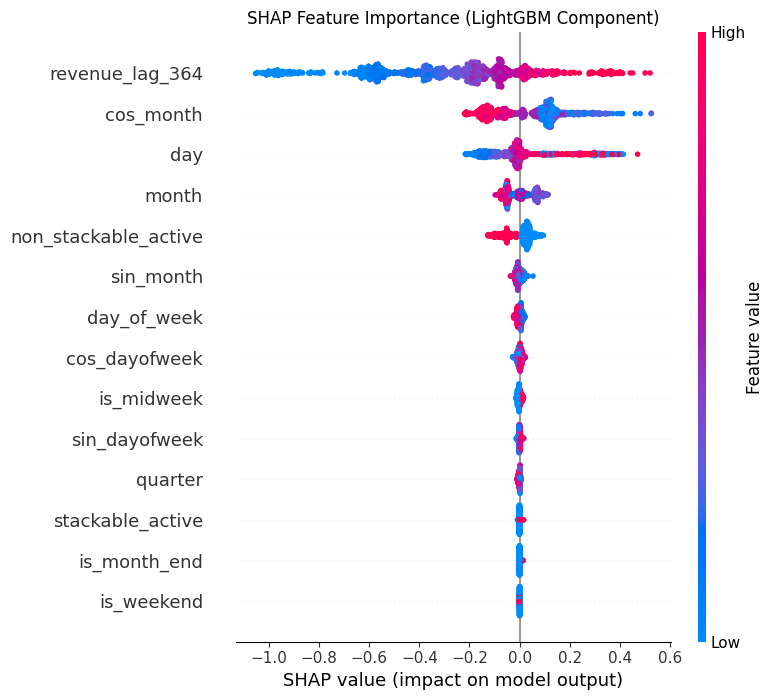


5. Đang dự báo tập Test và tạo file submission_v7_ensemble.csv...
Hoàn thành! Bạn đang có file 'submission_v7_ensemble.csv' mạnh nhất.
Biểu đồ SHAP cũng đã được lưu dưới tên 'shap_v7_ensemble.png'. Chúc bạn đạt TOP LB!


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path # Thêm dòng này
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')

print("=== BẢN CHỐT HẠ V7: ENSEMBLE XGBOOST + LIGHTGBM ===")



DATA_DIR = Path('../data') 
RAW_DIR = DATA_DIR / 'raw'

ANALYTICS_DIR = RAW_DIR / 'analytics-operational'
MASTER_DIR = RAW_DIR / 'master'

# ==============================================================================
# BƯỚC 1: LOAD DỮ LIỆU & LÀM SẠCH
# ==============================================================================
sales_train = pd.read_csv(ANALYTICS_DIR / 'sales.csv', parse_dates=['Date'])
sales_test = pd.read_csv(ANALYTICS_DIR / 'sample_submission.csv', parse_dates=['Date'])
sales_test['Revenue'] = np.nan
sales_test['COGS'] = np.nan

df_all = pd.concat([sales_train, sales_test], ignore_index=True).sort_values('Date').reset_index(drop=True)

promotions = pd.read_csv(MASTER_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])

# ==============================================================================
# BƯỚC 2: FEATURE ENGINEERING 
# ==============================================================================
print("2. Đang chế tạo Features an toàn tuyệt đối...")

dates_array = df_all['Date'].values
stackable_promos = promotions[promotions['stackable_flag'] == 1]
non_stackable_promos = promotions[promotions['stackable_flag'] == 0]

df_all['stackable_active'] = [((stackable_promos['start_date'] <= d) & (stackable_promos['end_date'] >= d)).sum() for d in dates_array]
df_all['non_stackable_active'] = [((non_stackable_promos['start_date'] <= d) & (non_stackable_promos['end_date'] >= d)).sum() for d in dates_array]

df_all['month'] = df_all['Date'].dt.month
df_all['day'] = df_all['Date'].dt.day
df_all['day_of_week'] = df_all['Date'].dt.dayofweek
df_all['is_midweek'] = df_all['day_of_week'].isin([1, 2, 3]).astype(int)
df_all['is_weekend'] = df_all['day_of_week'].isin([5, 6]).astype(int)
df_all['quarter'] = df_all['Date'].dt.quarter
df_all['is_month_end'] = df_all['Date'].dt.is_month_end.astype(int)

df_all['sin_month'] = np.sin(2 * np.pi * df_all['month']/12.0)
df_all['cos_month'] = np.cos(2 * np.pi * df_all['month']/12.0)
df_all['sin_dayofweek'] = np.sin(2 * np.pi * df_all['day_of_week']/7.0)
df_all['cos_dayofweek'] = np.cos(2 * np.pi * df_all['day_of_week']/7.0)

df_all['revenue_lag_364'] = df_all['Revenue'].shift(364)
df_all['cogs_lag_364'] = df_all['COGS'].shift(364)

df_all['revenue_lag_364'] = df_all.groupby('month')['revenue_lag_364'].transform(lambda x: x.fillna(x.mean()))
df_all['cogs_lag_364'] = df_all.groupby('month')['cogs_lag_364'].transform(lambda x: x.fillna(x.mean()))

train_df = df_all[df_all['Date'] <= '2022-12-31'].reset_index(drop=True)
test_df = df_all[df_all['Date'] >= '2023-01-01'].reset_index(drop=True)

features_rev = ['month', 'day', 'day_of_week', 'is_midweek', 'is_weekend', 'quarter', 'is_month_end',
                'sin_month', 'cos_month', 'sin_dayofweek', 'cos_dayofweek',
                'stackable_active', 'non_stackable_active', 'revenue_lag_364']

features_cogs = ['month', 'day', 'day_of_week', 'is_midweek', 'is_weekend', 'quarter', 'is_month_end',
                 'sin_month', 'cos_month', 'sin_dayofweek', 'cos_dayofweek',
                 'stackable_active', 'non_stackable_active', 'cogs_lag_364']


def train_ensemble(target_col, X, y):
    print(f"\n---> Đang huấn luyện ENSEMBLE cho: {target_col} <---")
    tscv = TimeSeriesSplit(n_splits=5)
    
    oof_preds_lgb = np.zeros(len(X))
    oof_preds_xgb = np.zeros(len(X))
    
    models_lgb = []
    models_xgb = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # Log Transform
        y_train_log = np.log1p(y_train)
        y_val_log = np.log1p(y_val)
        
        # 1. LIGHTGBM
        model_lgb = lgb.LGBMRegressor(
            objective='rmse', n_estimators=1000, learning_rate=0.03, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
        )
        model_lgb.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], callbacks=[lgb.early_stopping(50, verbose=False)])
        
        # 2. XGBOOST
        model_xgb = xgb.XGBRegressor(
            objective='reg:squarederror', n_estimators=1000, learning_rate=0.03, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, random_state=42, early_stopping_rounds=50, verbosity=0
        )
        model_xgb.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)
        
        models_lgb.append(model_lgb)
        models_xgb.append(model_xgb)
        
        pred_lgb = np.expm1(model_lgb.predict(X_val))
        pred_xgb = np.expm1(model_xgb.predict(X_val))
        
        oof_preds_lgb[val_idx] = pred_lgb
        oof_preds_xgb[val_idx] = pred_xgb
        
        # Ensemble: Trọng số 50-50
        fold_pred = 0.5 * pred_lgb + 0.5 * pred_xgb
        rmse = np.sqrt(mean_squared_error(y_val, fold_pred))
        print(f"Fold {fold+1} | RMSE: {rmse:.2f}")

    # Đánh giá tổng OOF
    valid_idx = np.where(oof_preds_lgb > 0)[0]
    final_pred = 0.5 * oof_preds_lgb[valid_idx] + 0.5 * oof_preds_xgb[valid_idx]
    final_rmse = np.sqrt(mean_squared_error(y.iloc[valid_idx], final_pred))
    final_r2 = r2_score(y.iloc[valid_idx], final_pred)
    
    print(f"\n[KẾT QUẢ ENSEMBLE {target_col}] RMSE: {final_rmse:.2f} | R2: {final_r2:.4f}")
    return models_lgb, models_xgb

models_rev_lgb, models_rev_xgb = train_ensemble('Revenue', train_df[features_rev], train_df['Revenue'])
models_cogs_lgb, models_cogs_xgb = train_ensemble('COGS', train_df[features_cogs], train_df['COGS'])

# ==============================================================================
# BƯỚC 4: VẼ BIỂU ĐỒ SHAP (Dùng XGBoost làm đại diện)
# ==============================================================================
print("\n4. Đang tính toán và xuất Plot SHAP (Bằng LightGBM)...")
# Lấy mô hình LightGBM ở fold cuối để tránh lỗi parse của XGBoost
best_lgb_rev = models_rev_lgb[-1] 

explainer = shap.TreeExplainer(best_lgb_rev)
shap_data = train_df[features_rev].iloc[-1000:] 
shap_values = explainer.shap_values(shap_data)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_data, show=False)
plt.title("SHAP Feature Importance (LightGBM Component)")
plt.tight_layout()
plt.savefig('shap_v7_ensemble.png', dpi=300)
plt.show()

# ==============================================================================
# BƯỚC 5: XUẤT SUBMISSION
# ==============================================================================
print("\n5. Đang dự báo tập Test và tạo file submission_v7_ensemble.csv...")

# Tính trung bình cộng của 5 folds, sau đó ensemble 50/50 giữa LGBM và XGB
test_pred_rev_lgb = np.mean([np.expm1(m.predict(test_df[features_rev])) for m in models_rev_lgb], axis=0)
test_pred_rev_xgb = np.mean([np.expm1(m.predict(test_df[features_rev])) for m in models_rev_xgb], axis=0)
final_test_rev = 0.5 * test_pred_rev_lgb + 0.5 * test_pred_rev_xgb

test_pred_cogs_lgb = np.mean([np.expm1(m.predict(test_df[features_cogs])) for m in models_cogs_lgb], axis=0)
test_pred_cogs_xgb = np.mean([np.expm1(m.predict(test_df[features_cogs])) for m in models_cogs_xgb], axis=0)
final_test_cogs = 0.5 * test_pred_cogs_lgb + 0.5 * test_pred_cogs_xgb

test_df['Revenue'] = np.clip(final_test_rev, a_min=0, a_max=None)
test_df['COGS'] = np.clip(final_test_cogs, a_min=0, a_max=None)

submission = test_df[['Date', 'Revenue', 'COGS']]
submission.to_csv('submission_v7_ensemble.csv', index=False)
print("Hoàn thành! Bạn đang có file 'submission_v7_ensemble.csv' mạnh nhất.")
print("Biểu đồ SHAP cũng đã được lưu dưới tên 'shap_v7_ensemble.png'. Chúc bạn đạt TOP LB!")